# Constrained Bayesian logistic regression

The paper's Section 3.3 synthetic experiment, with their $J$ fields and with anchored Langevin.
Data model exactly as their Eq. (3.13):

$$X_j\sim\mathcal N(0,2I_3),\qquad p_j\sim U(0,1),\qquad
y_j=\mathbf 1\Bigl\{p_j\le\bigl(1+e^{-\beta_*^\top X_j}\bigr)^{-1}\Bigr\},$$

with $n=2000$, uniform prior on $K$, minibatch $m=50$, stepsize $\eta=10^{-4}$, **1000 iterations**,
a 20% test split, and their skew parameters $a=1$ for $J_a$ and $s=10$ for $J_s$ / $J_g$. Constraint sets:
the unit ball and the smoothed $\ell_p$ ball ($p=4$, $\varepsilon=0.2$, $\lambda=1$).

The paper does not state $\beta_*$; this notebook uses $\beta_*=[1,-0.7,-0.5]^\top$, the $x_*$ from their
linear-regression experiment. Its norm is $1.32>1$, so **the truth lies outside $K$** and the constraint is
active, as in their Figure 6/8. The resulting Bayes-optimal accuracy is about $77\%$ — that is the ceiling
every curve below is climbing toward, and it is a property of this $\beta_*$ and the noise in (3.13).

## Temperature, again

Same fork as in the linear-regression notebook: the target is written as a sum over data, the SGLD uses
the average gradient. Writing $\pi(\beta)\propto\exp\bigl(-\frac{\beta_T}{n}\sum_j\ell_j(\beta)\bigr)\mathbf 1_K$
with $\ell_j$ the logistic negative log-likelihood,

* $\beta_T=n$ (the exact posterior): s.d. $\approx0.05$. Statistically correct, but the paper's $s=10$ is
  catastrophic there — the skew drift is $2s\lVert x\rVert\approx20$ times the gradient, and the gradient
  itself is $\sim700$, so at $\eta=10^{-4}$ the ensemble is thrown onto the boundary and accuracy collapses
  to $0.51$, i.e. chance. Measured in Experiment 4.
* $\beta_T=1$: nearly uniform on $K$, the data washed out.
* $\beta_T=100$ (used here): s.d. $\approx0.2$, and **every one of the paper's parameters
  ($\eta=10^{-4}$, $a=1$, $s=10$, 1000 iterations) is usable**. This is the regime their figures live in.

## A reference the paper says is impractical

They write that computing $W_1$ against the posterior "is not practical" for logistic regression, and use
accuracy instead. In $d=3$ it *is* practical: evaluate the unnormalised log-posterior on a grid over $K$
($\approx1.9$M points inside the ball), normalise, and sample. That gives an essentially exact reference —
verified stable to 4 decimals under grid refinement — so this notebook reports their accuracy curves **and**
$W_1$.

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import wasserstein_distance

In [2]:
# -----------------------------
# Data, exactly the paper's Eq. (3.13)
# -----------------------------
d        = 3
n_data   = 2000
BATCH    = 50
BETA_T   = 100.0        # inverse temperature, see the header
N        = 2000         # particles
max_iter = 1000         # the paper's horizon
eta      = 1e-4
SEED     = 1006
LAM      = 1.0
P_LP, EPS_LP = 4.0, 0.2
TRACK_ACC, TRACK_W1 = 5, 20

rng = np.random.default_rng(SEED)
beta_star = np.array([1.0, -0.7, -0.5])
Xall = rng.normal(0.0, np.sqrt(2.0), size=(n_data, d))
prob = 1.0 / (1.0 + np.exp(-Xall @ beta_star))
Yall = (rng.uniform(size=n_data) <= prob).astype(float)

n_tr = int(0.8 * n_data)
Xtr, Ytr, Xte, Yte = Xall[:n_tr], Yall[:n_tr], Xall[n_tr:], Yall[n_tr:]
Xt, Yt = torch.tensor(Xtr), torch.tensor(Ytr)

print("n = {} (train {} / test {}),  label balance {:.3f}".format(n_data, n_tr, n_data - n_tr, Yall.mean()))
print("||beta_*|| = {:.4f}  -> outside K: {}".format(np.linalg.norm(beta_star), np.linalg.norm(beta_star) > 1))

n = 2000 (train 1600 / test 400),  label balance 0.489
||beta_*|| = 1.3191  -> outside K: True


In [3]:
# -----------------------------
# Potential: tempered logistic negative log-likelihood, uniform prior on K
# -----------------------------
SC = BETA_T / n_tr

@torch.no_grad()
def negloglik(B, Xd=None, Yd=None):
    Xd = Xt if Xd is None else Xd; Yd = Yt if Yd is None else Yd
    z = B @ Xd.T
    return torch.sum(torch.nn.functional.softplus(z) - Yd * z, dim=1)

@torch.no_grad()
def grad_U_batch(B, gen):
    idx = torch.randint(0, n_tr, (BATCH,), generator=gen)
    Xb, Yb = Xt[idx], Yt[idx]
    return ((torch.sigmoid(B @ Xb.T) - Yb) @ Xb) * (n_tr / BATCH) * SC

@torch.no_grad()
def grad_U_full(B):
    return ((torch.sigmoid(B @ Xt.T) - Yt) @ Xt) * SC

# -----------------------------
# Constraints, projections, skew fields (as in the linear-regression notebook)
# -----------------------------
def g_ball(x):      return torch.sum(x * x, dim=1)
def grad_g_ball(x): return 2 * x
def g_lp(x):        return torch.sum((x * x + EPS_LP ** 2) ** (P_LP / 2), dim=1)
def grad_g_lp(x):   return P_LP * x * (x * x + EPS_LP ** 2) ** (P_LP / 2 - 1)

@torch.no_grad()
def proj_ball(x):
    nn = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(1.0 / nn, max=1.0)

@torch.no_grad()
def proj_lp(x, iters=15):
    x = x.clone()
    for _ in range(iters):
        gv = g_lp(x); m = gv > LAM
        if not m.any(): break
        gg = grad_g_lp(x[m])
        x[m] = x[m] - ((gv[m] - LAM) / (gg.norm(dim=1) ** 2 + 1e-12)).unsqueeze(1) * gg
    gv = g_lp(x); m = gv > LAM
    if m.any():
        xm = x[m]; lo = torch.zeros(xm.shape[0]); hi = torch.ones(xm.shape[0])
        for _ in range(40):
            mid = (lo + hi) / 2
            over = g_lp(xm * mid.unsqueeze(1)) > LAM
            hi = torch.where(over, mid, hi); lo = torch.where(over, lo, mid)
        x[m] = xm * lo.unsqueeze(1)
    return x

PROJ = {"ball": proj_ball, "lp": proj_lp}
GFUN = {"ball": g_ball,    "lp": g_lp}

def J_const_mat(a):
    return torch.diag(a * torch.ones(d - 1), diagonal=1) + torch.diag(-a * torch.ones(d - 1), diagonal=-1)

@torch.no_grad()
def skew_apply(x, v, field, s, setname):
    if field == "none":  return torch.zeros_like(v)
    if field == "const": return v @ J_const_mat(s).T
    k = -s * (grad_g_ball(x) if setname == "ball" else grad_g_lp(x))    # k = grad[(lam - g)]
    return torch.cross(k, v, dim=1)

In [4]:
# -----------------------------
# Grid reference: the exact constrained posterior, in d = 3
# -----------------------------
def log_post_grid(M, chunk=20000):
    out = np.empty(len(M))
    for i in range(0, len(M), chunk):
        out[i:i + chunk] = -SC * negloglik(torch.tensor(M[i:i + chunk])).numpy()
    return out

def grid_reference(setname, G=161, n_ref=N, seed=0, nll=None):
    rr = np.random.default_rng(seed)
    ax = np.linspace(-1.05, 1.05, G)
    M = np.stack(np.meshgrid(ax, ax, ax, indexing="ij"), -1).reshape(-1, 3)
    inside = (np.linalg.norm(M, axis=1) <= 1.0) if setname == "ball" else (g_lp(torch.tensor(M)).numpy() <= LAM)
    M = M[inside]
    lp = log_post_grid(M) if nll is None else nll(M)
    lp -= lp.max(); w = np.exp(lp); w /= w.sum()
    cell = 2.1 / (G - 1)
    R = M[rr.choice(len(M), size=int(1.3 * n_ref), p=w)] + rr.uniform(-cell / 2, cell / 2, size=(int(1.3 * n_ref), 3))
    keep = (np.linalg.norm(R, axis=1) <= 1.0) if setname == "ball" else (g_lp(torch.tensor(R)).numpy() <= LAM)
    return R[keep][:n_ref], len(M)

def accuracy(B, Xd, Yd):
    return ((1.0 / (1.0 + np.exp(-Xd @ B.T)) > 0.5).astype(float) == Yd[:, None]).mean(axis=0)

def on_boundary(setname, X):
    v = np.linalg.norm(X, axis=1) if setname == "ball" else g_lp(torch.tensor(X)).numpy()
    return float(np.mean(v > 0.999))

refs, floors = {}, {}
for setname in ["ball", "lp"]:
    refs[setname], npts = grid_reference(setname)
    r2, _ = grid_reference(setname, seed=7)
    floors[setname] = [wasserstein_distance(refs[setname][:, i], r2[:, i]) for i in range(d)]
    print("{:<5} grid pts {:>9}  mean {}  sd {}  boundary {:.3f}  W1 floor {}".format(
        setname, npts, np.round(refs[setname].mean(0), 3), np.round(refs[setname].std(0), 3),
        on_boundary(setname, refs[setname]), np.round(floors[setname], 4)))
    print("      reference accuracy: train {:.4f}  test {:.4f}".format(
        accuracy(refs[setname], Xtr, Ytr).mean(), accuracy(refs[setname], Xte, Yte).mean()))
print("\naccuracy at beta_* : train {:.4f}  test {:.4f}   <- the ceiling".format(
    accuracy(beta_star[None], Xtr, Ytr)[0], accuracy(beta_star[None], Xte, Yte)[0]))

ball  grid pts   1852269  mean [ 0.677 -0.476 -0.298]  sd [0.116 0.132 0.142]  boundary 0.004  W1 floor [0.0032 0.0047 0.0053]
      reference accuracy: train 0.7611  test 0.7536


lp    grid pts   2631765  mean [ 0.764 -0.572 -0.374]  sd [0.115 0.143 0.16 ]  boundary 0.000  W1 floor [0.0031 0.006  0.0038]
      reference accuracy: train 0.7624  test 0.7570

accuracy at beta_* : train 0.7681  test 0.7725   <- the ceiling


In [5]:
# -----------------------------
# SRNSGLD / PSGLD for the logistic posterior
# -----------------------------
def run_chain(setname, field, s, eta=eta, n_steps=max_iter, N=N, ref=None, seed=SEED,
              track=True, stochastic=True, anchored=False, b_prior=None, delta_h=0.1):
    proj = PROJ[setname]
    torch.manual_seed(seed); gen = torch.Generator().manual_seed(seed)
    x = torch.zeros(N, d)
    accs_tr, accs_te, W = [], [], []
    for it in range(n_steps):
        g = grad_U_batch(x, gen) if stochastic else grad_U_full(x)
        if anchored:                                    # Laplace prior: U0 = pseudo-Huber surrogate
            Delta = (torch.sum(torch.abs(x), dim=1) - torch.sum(torch.sqrt(x * x + delta_h ** 2), dim=1)) / b_prior
            g = (g + (x / torch.sqrt(x * x + delta_h ** 2)) / b_prior) * torch.exp(Delta).unsqueeze(1)
            noise_scale = torch.exp(0.5 * Delta).unsqueeze(1)
        else:
            noise_scale = 1.0
        drift = g + skew_apply(x, g, field, s, setname)
        x = proj(x - eta * drift + np.sqrt(2 * eta) * noise_scale * torch.randn_like(x))
        if track and it % TRACK_ACC == 0:
            xn = x.numpy()
            accs_tr.append(accuracy(xn, Xtr, Ytr)); accs_te.append(accuracy(xn, Xte, Yte))
        if track and ref is not None and it % TRACK_W1 == 0:
            xn = x.numpy()
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return (x.numpy(), np.array(accs_tr) if accs_tr else None,
            np.array(accs_te) if accs_te else None, np.array(W) if W else None)

## Experiment 1 — ball constraint: the paper's Figure 10

Accuracy on the training and test sets against iteration, mean $\pm$ one standard deviation across the
particle ensemble, exactly as they plot it.

In [6]:
METHODS = [("none", 0.0, "PSGLD (J = 0)"),
           ("const", 1.0, "SRNSGLD ($J_a$, a = 1)"),
           ("state", 10.0, "SRNSGLD ($J_s$, s = 10)")]
COL = {"PSGLD (J = 0)": "#DD8452", "SRNSGLD ($J_a$, a = 1)": "#4C72B0", "SRNSGLD ($J_s$, s = 10)": "#55A868"}

exp1 = {}
for field, s, lab in METHODS:
    xf, atr, ate, W = run_chain("ball", field, s, ref=refs["ball"])
    exp1[lab] = {"x": xf, "atr": atr, "ate": ate, "W1": W}
    print("{:<26} train {:.4f}+/-{:.4f}   test {:.4f}+/-{:.4f}   W1 {}   boundary {:.3f}".format(
        lab.replace("$", ""), atr[-1].mean(), atr[-1].std(), ate[-1].mean(), ate[-1].std(),
        np.round(W[-5:].mean(axis=0), 4), on_boundary("ball", xf)))
print("{:<26} train {:.4f}          test {:.4f}          W1 {}   boundary {:.3f}".format(
    "exact posterior", accuracy(refs["ball"], Xtr, Ytr).mean(), accuracy(refs["ball"], Xte, Yte).mean(),
    np.round(floors["ball"], 4), on_boundary("ball", refs["ball"])))

PSGLD (J = 0)              train 0.7614+/-0.0087   test 0.7544+/-0.0132   W1 [0.0034 0.0119 0.0101]   boundary 0.089


SRNSGLD (J_a, a = 1)       train 0.7550+/-0.0116   test 0.7506+/-0.0144   W1 [0.0759 0.1723 0.0301]   boundary 0.155


SRNSGLD (J_s, s = 10)      train 0.7413+/-0.0240   test 0.7308+/-0.0296   W1 [0.1222 0.1329 0.128 ]   boundary 0.150
exact posterior            train 0.7611          test 0.7536          W1 [0.0032 0.0047 0.0053]   boundary 0.004


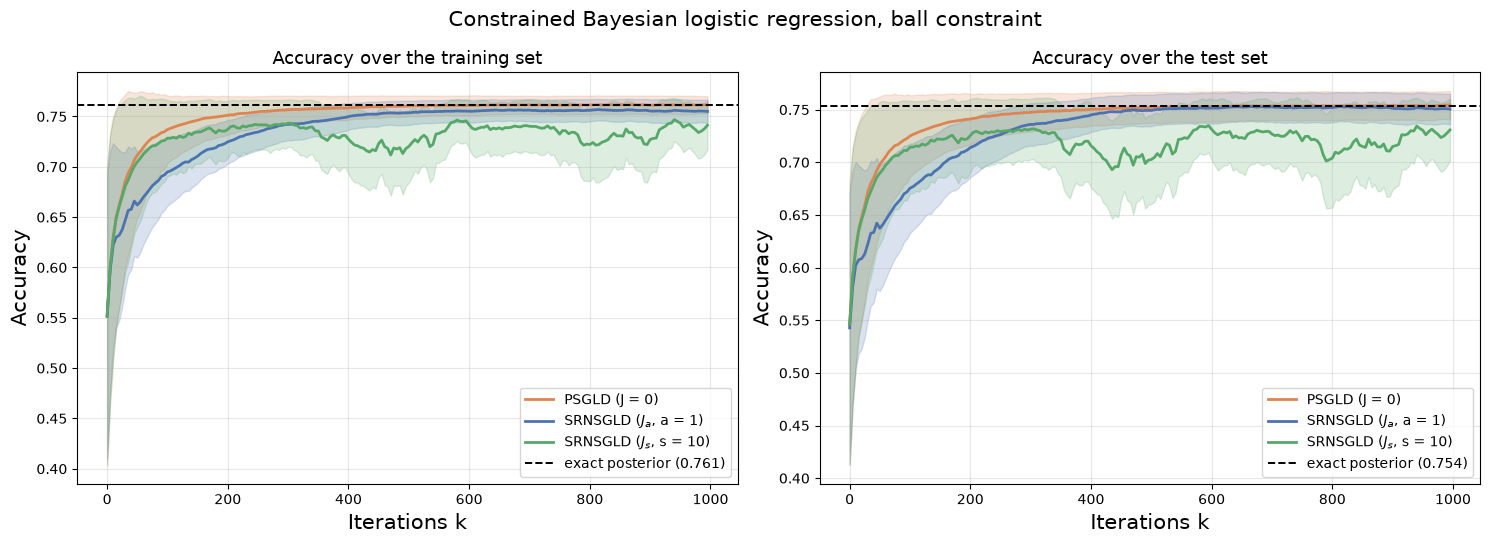

In [7]:
def accuracy_panel(store, setname, title, fname):
    it = np.arange(len(next(iter(store.values()))["atr"])) * TRACK_ACC
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for ax, key, name in [(axes[0], "atr", "training set"), (axes[1], "ate", "test set")]:
        for _, _, lab in METHODS:
            a = store[lab][key]
            ax.plot(it, a.mean(axis=1), linewidth=2, color=COL[lab], label=lab)
            ax.fill_between(it, a.mean(axis=1) - a.std(axis=1), a.mean(axis=1) + a.std(axis=1),
                            color=COL[lab], alpha=0.20)
        ref_acc = accuracy(refs[setname], Xtr if key == "atr" else Xte, Ytr if key == "atr" else Yte).mean()
        ax.axhline(ref_acc, color="k", linestyle="--", linewidth=1.4,
                   label="exact posterior ({:.3f})".format(ref_acc))
        ax.set_xlabel("Iterations k", fontsize=15); ax.set_ylabel("Accuracy", fontsize=15)
        ax.set_title("Accuracy over the " + name, fontsize=13)
        ax.grid(alpha=0.3); ax.legend(fontsize=10, loc="lower right")
    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

accuracy_panel(exp1, "ball", "Constrained Bayesian logistic regression, ball constraint",
               "figures/blogit_ball_accuracy.pdf")

### New: $W_1$ against the exact posterior, and the sampled densities

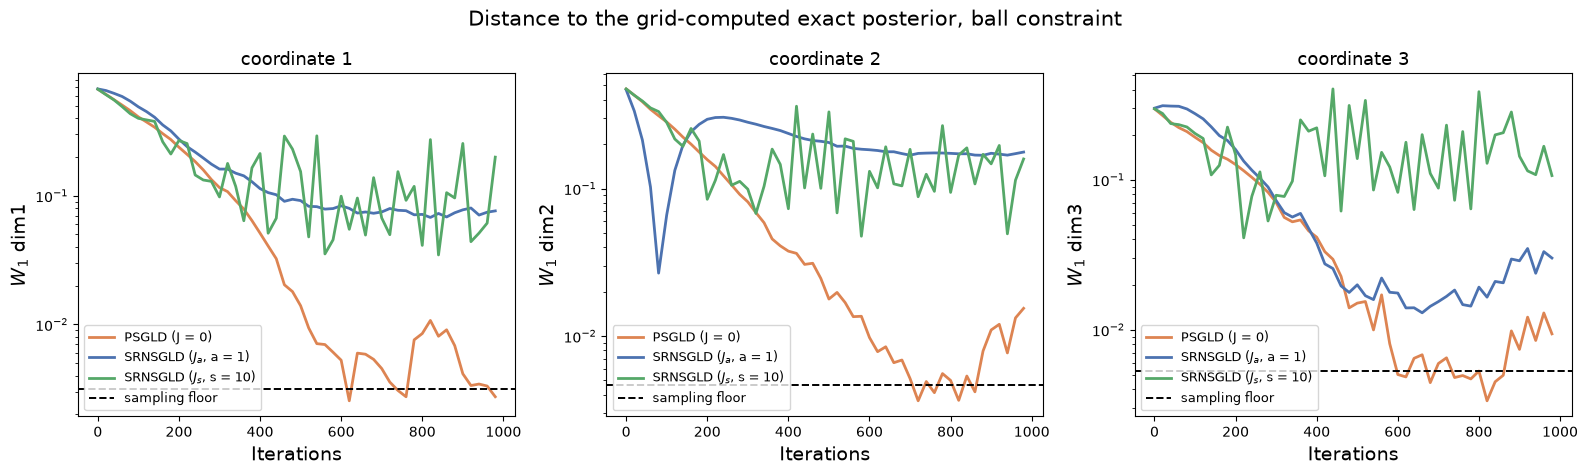

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
it = np.arange(len(exp1[METHODS[0][2]]["W1"])) * TRACK_W1
for i, ax in enumerate(axes):
    for _, _, lab in METHODS:
        ax.plot(it, exp1[lab]["W1"][:, i], linewidth=2, color=COL[lab], label=lab)
    ax.axhline(floors["ball"][i], color="k", linestyle="--", linewidth=1.4, label="sampling floor")
    ax.set_yscale("log"); ax.set_xlabel("Iterations", fontsize=14)
    ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=14)
    ax.set_title("coordinate {}".format(i + 1), fontsize=13); ax.legend(fontsize=9)
fig.suptitle("Distance to the grid-computed exact posterior, ball constraint", fontsize=15)
plt.tight_layout()
plt.savefig("figures/blogit_ball_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

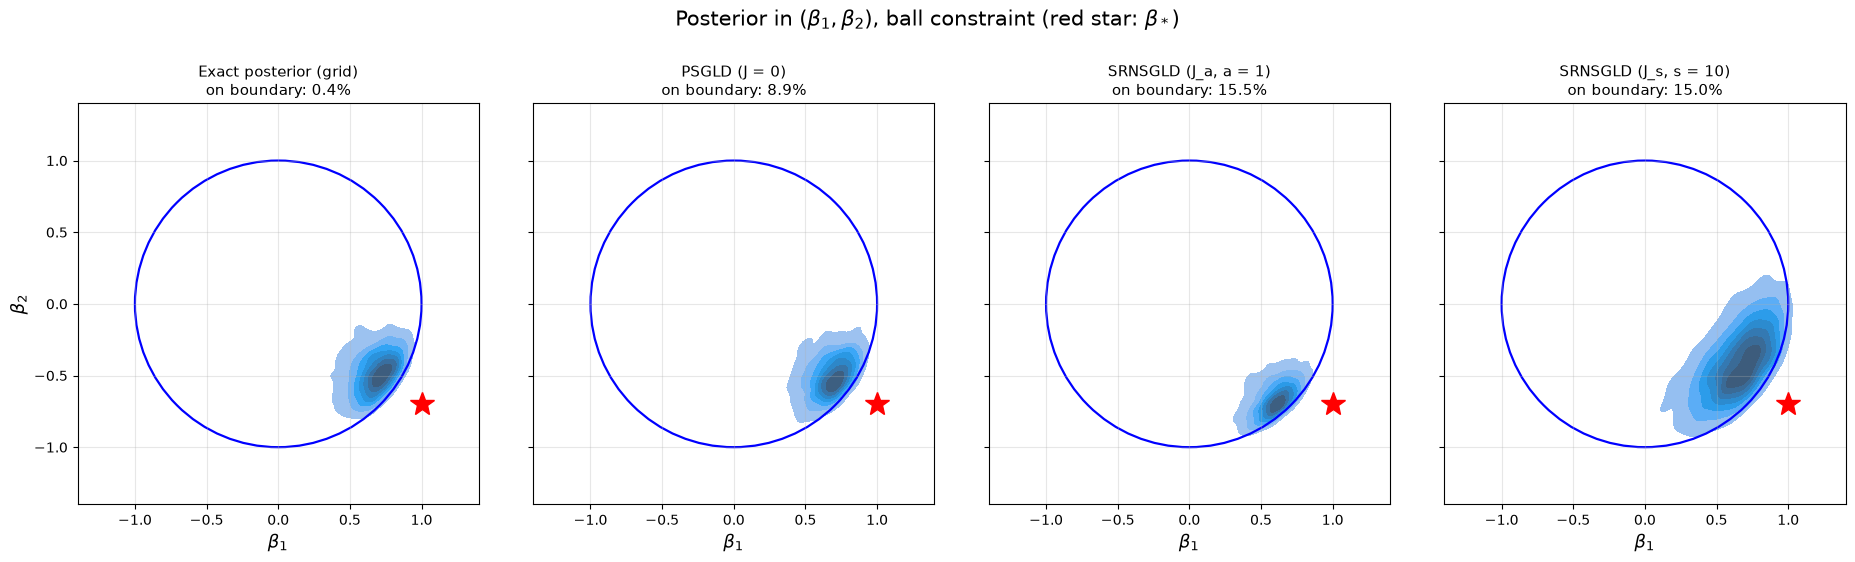

In [9]:
def density_panel(store, setname, title, fname, boundary_xy=None):
    panels = [("Exact posterior (grid)", refs[setname])] + [(lab, store[lab]["x"]) for _, _, lab in METHODS]
    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
        if boundary_xy is None:
            ax.add_patch(Circle((0, 0), 1.0, edgecolor="b", facecolor="none", linewidth=1.6))
        else:
            ax.plot(*boundary_xy, "b-", linewidth=1.6)
        ax.plot([beta_star[0]], [beta_star[1]], "r*", markersize=18)
        ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
        ax.set_title("{}\non boundary: {:.1%}".format(name.replace("$", ""), on_boundary(setname, X)), fontsize=11)
        ax.set_xlabel(r"$\beta_1$", fontsize=13); ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="box")
    axes[0].set_ylabel(r"$\beta_2$", fontsize=13)
    fig.suptitle(title, fontsize=15, y=1.05)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

density_panel(exp1, "ball", r"Posterior in $(\beta_1,\beta_2)$, ball constraint (red star: $\beta_*$)",
              "figures/blogit_ball_density.pdf")

## Experiment 2 — smoothed $\ell_p$ ball: the paper's Figure 11

PSGLD (J = 0)              train 0.7624+/-0.0075   test 0.7570+/-0.0118   W1 [0.0051 0.0059 0.0218]   boundary 0.053


SRNSGLD (J_a, a = 1)       train 0.7609+/-0.0076   test 0.7584+/-0.0112   W1 [0.0201 0.1064 0.0104]   boundary 0.076


SRNSGLD (J_s, s = 10)      train 0.6528+/-0.0713   test 0.6341+/-0.0713   W1 [0.3161 0.2931 0.4112]   boundary 0.322
exact posterior            train 0.7624          test 0.7570


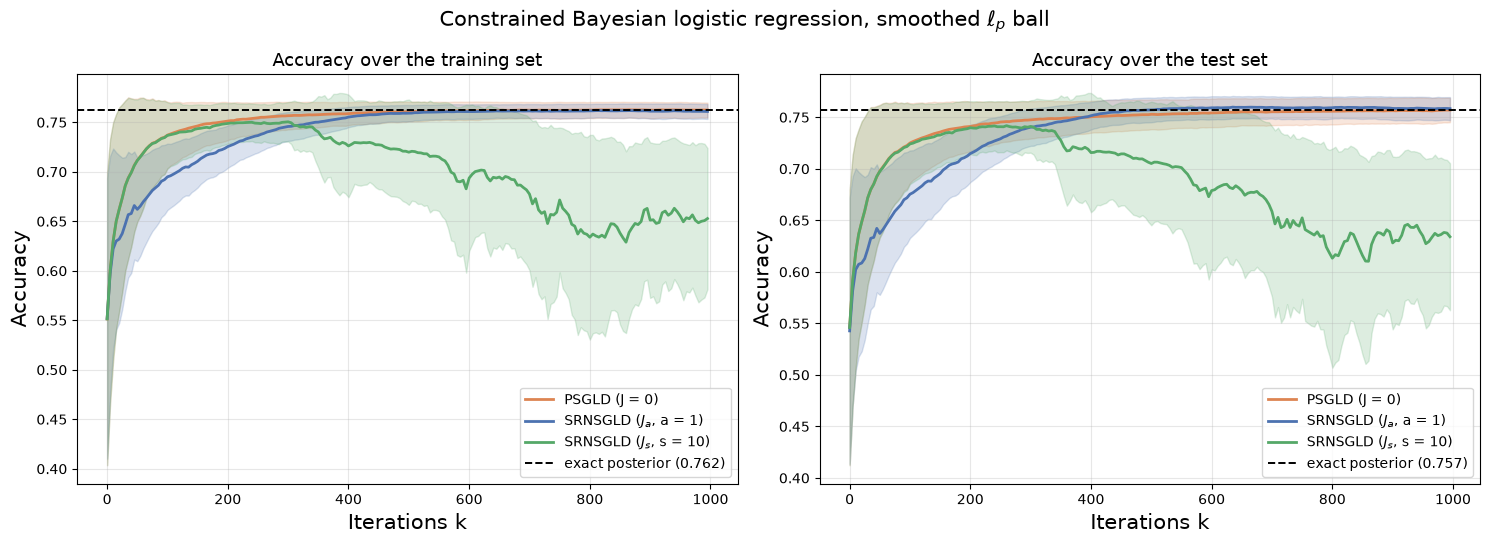

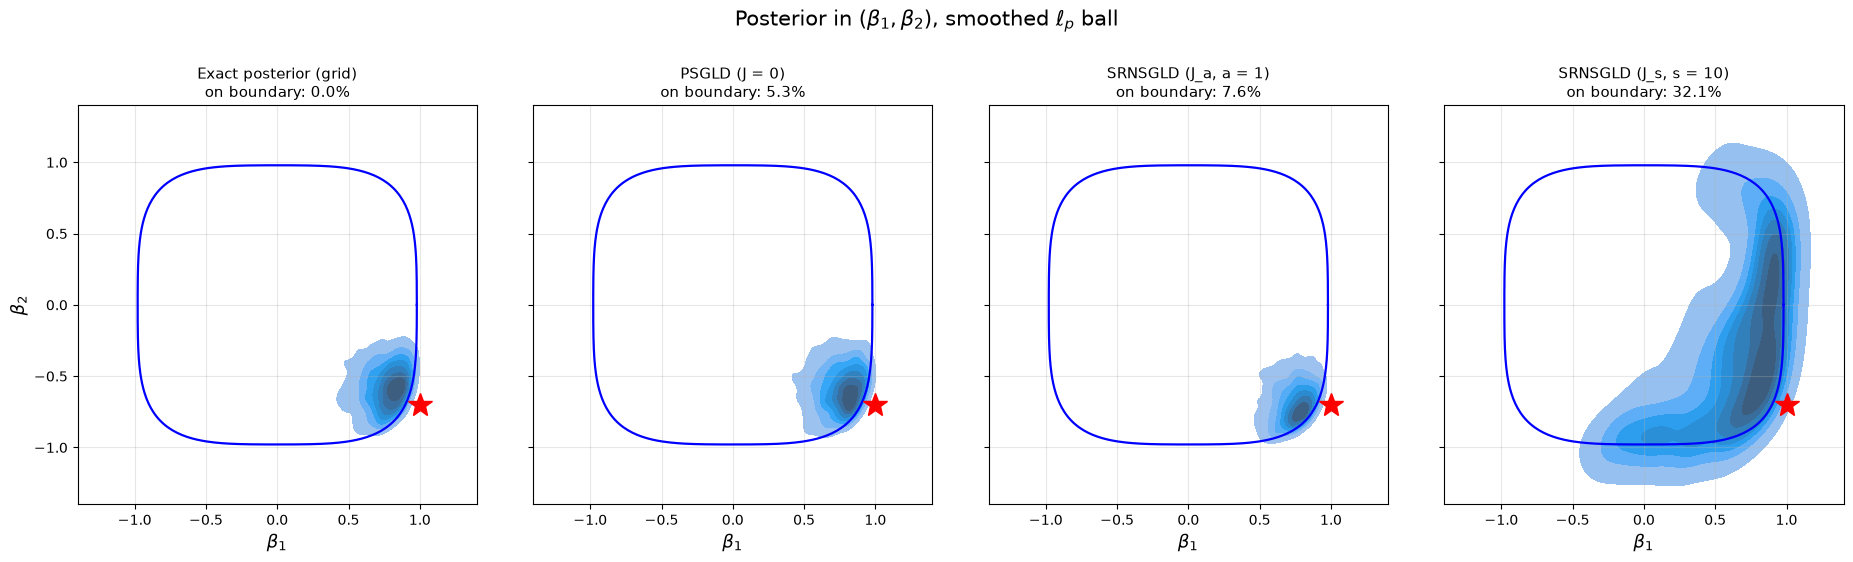

In [10]:
exp2 = {}
for field, s, lab in METHODS:
    xf, atr, ate, W = run_chain("lp", field, s, ref=refs["lp"])
    exp2[lab] = {"x": xf, "atr": atr, "ate": ate, "W1": W}
    print("{:<26} train {:.4f}+/-{:.4f}   test {:.4f}+/-{:.4f}   W1 {}   boundary {:.3f}".format(
        lab.replace("$", ""), atr[-1].mean(), atr[-1].std(), ate[-1].mean(), ate[-1].std(),
        np.round(W[-5:].mean(axis=0), 4), on_boundary("lp", xf)))
print("{:<26} train {:.4f}          test {:.4f}".format(
    "exact posterior", accuracy(refs["lp"], Xtr, Ytr).mean(), accuracy(refs["lp"], Xte, Yte).mean()))

accuracy_panel(exp2, "lp", r"Constrained Bayesian logistic regression, smoothed $\ell_p$ ball",
               "figures/blogit_lp_accuracy.pdf")

th = np.linspace(0, 2 * np.pi, 400)
uu = np.stack([np.cos(th), np.sin(th), np.zeros_like(th)], 1)
lo, hi = np.zeros(len(th)), np.full(len(th), 5.0)
for _ in range(60):
    mid = (lo + hi) / 2
    over = g_lp(torch.tensor(uu * mid[:, None])).numpy() > LAM
    hi = np.where(over, mid, hi); lo = np.where(over, lo, mid)
density_panel(exp2, "lp", r"Posterior in $(\beta_1,\beta_2)$, smoothed $\ell_p$ ball",
              "figures/blogit_lp_density.pdf",
              boundary_xy=((lo + hi) / 2 * np.cos(th), (lo + hi) / 2 * np.sin(th)))

## Experiment 3 — new: the temperature, and why $\beta_T=100$

$\beta_T$ decides whether the posterior is a point mass, an informative distribution, or the prior.

beta_T = 1.0     posterior sd 0.438   mean [ 0.058 -0.041 -0.026]   test acc 0.5231   boundary 0.002


beta_T = 10.0    posterior sd 0.331   mean [ 0.393 -0.282 -0.179]   test acc 0.6602   boundary 0.002


beta_T = 100.0   posterior sd 0.129   mean [ 0.676 -0.477 -0.297]   test acc 0.7534   boundary 0.005


beta_T = 400.0   posterior sd 0.065   mean [ 0.737 -0.517 -0.322]   test acc 0.7634   boundary 0.014


beta_T = 1600.0  posterior sd 0.033   mean [ 0.76  -0.532 -0.333]   test acc 0.7684   boundary 0.041


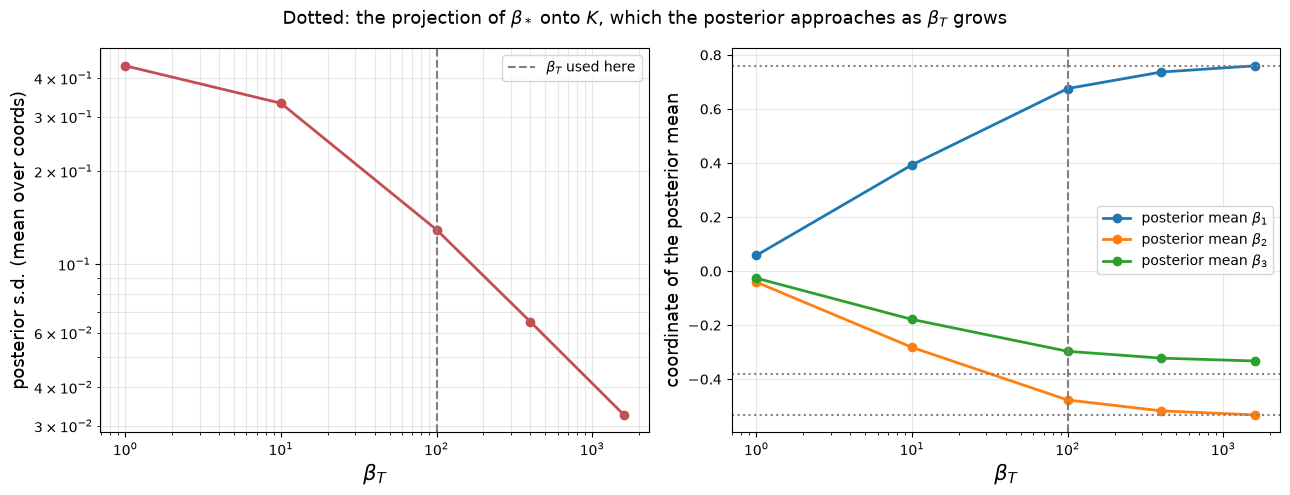

In [11]:
BT_LIST = [1.0, 10.0, 100.0, 400.0, 1600.0]
rows = []
_sc = SC
for bt in BT_LIST:
    SC = bt / n_tr
    R, _ = grid_reference("ball", G=121, n_ref=4000, seed=3)
    rows.append((bt, R.std(0).mean(), R.mean(0), accuracy(R, Xte, Yte).mean(), on_boundary("ball", R)))
    print("beta_T = {:<7} posterior sd {:.3f}   mean {}   test acc {:.4f}   boundary {:.3f}".format(
        bt, rows[-1][1], np.round(rows[-1][2], 3), rows[-1][3], rows[-1][4]))
SC = _sc

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(BT_LIST, [r[1] for r in rows], "-o", linewidth=2, color="#C44E52")
axes[0].axvline(BETA_T, color="gray", linestyle="--", label=r"$\beta_T$ used here")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel(r"$\beta_T$", fontsize=15); axes[0].set_ylabel("posterior s.d. (mean over coords)", fontsize=13)
axes[0].grid(alpha=0.3, which="both"); axes[0].legend(fontsize=10)
for j, nm in enumerate([r"$\beta_1$", r"$\beta_2$", r"$\beta_3$"]):
    axes[1].plot(BT_LIST, [r[2][j] for r in rows], "-o", linewidth=2, label="posterior mean " + nm)
    axes[1].axhline(beta_star[j] / np.linalg.norm(beta_star), linestyle=":", color="gray")
axes[1].set_xscale("log"); axes[1].set_xlabel(r"$\beta_T$", fontsize=15)
axes[1].set_ylabel("coordinate of the posterior mean", fontsize=13)
axes[1].axvline(BETA_T, color="gray", linestyle="--")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=10)
fig.suptitle(r"Dotted: the projection of $\beta_*$ onto $K$, which the posterior approaches as $\beta_T$ grows",
             fontsize=13)
plt.tight_layout()
plt.savefig("figures/blogit_temperature.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 4 — new: where the paper's $s=10$ breaks

The skew drift is $\lVert J\nabla U\rVert = 2s\lVert x\rVert\lVert\nabla U\rVert$, i.e. **$20\times$ the
gradient** at $s=10$ on the boundary — a ratio that is independent of scale. What is *not* scale-free is the
displacement it produces, $\eta\lVert J\nabla U\rVert$, and a logistic posterior at $\beta_T=n$ has
$\lVert\nabla U\rVert\approx700$. The table sweeps both the temperature and the stepsize.

In [12]:
print("{:<10}{:<10}{:<26}{:>12}{:>12}{:>14}".format("beta_T", "eta", "method", "test acc", "sd", "on boundary"))
print("-" * 86)
stab = {}
_sc = SC
for bt, et in [(1600.0, 1e-4), (1600.0, 1e-5), (100.0, 1e-4), (100.0, 3e-5)]:
    SC = bt / n_tr
    for field, s, lab in METHODS:
        xf, _, _, _ = run_chain("ball", field, s, eta=et, track=False)
        a = accuracy(xf, Xte, Yte)
        stab[(bt, et, lab)] = (a.mean(), xf.std(0).mean(), on_boundary("ball", xf))
        print("{:<10}{:<10}{:<26}{:>12.4f}{:>12.4f}{:>14.3f}".format(bt, et, lab.replace("$", ""), *stab[(bt, et, lab)]))
    print()
SC = _sc
print("reference (beta_T = {}): test acc {:.4f}".format(BETA_T, accuracy(refs["ball"], Xte, Yte).mean()))

beta_T    eta       method                        test acc          sd   on boundary
--------------------------------------------------------------------------------------


1600.0    0.0001    PSGLD (J = 0)                   0.7673      0.0328         0.581


1600.0    0.0001    SRNSGLD (J_a, a = 1)            0.7576      0.0306         0.599


1600.0    0.0001    SRNSGLD (J_s, s = 10)           0.5051      0.0570         1.000



1600.0    1e-05     PSGLD (J = 0)                   0.7679      0.0317         0.283


...

100.0     0.0001    SRNSGLD (J_a, a = 1)            0.7504      0.1146         0.155


100.0     0.0001    SRNSGLD (J_s, s = 10)           0.7318      0.2002         0.150



100.0     3e-05     PSGLD (J = 0)                   0.7480      0.1453         0.011


100.0     3e-05     SRNSGLD (J_a, a = 1)            0.7368      0.1104         0.130


100.0     3e-05     SRNSGLD (J_s, s = 10)           0.7458      0.1565         0.014

reference (beta_T = 100.0): test acc 0.7536


## Experiment 5 — new: a non-differentiable prior, where the anchoring works

Everything above has a smooth $U$ (logistic likelihood + uniform prior), so the anchor recipe returns
$U_0=U$ and "anchored" is just SGLD. Replacing the uniform prior with a Laplace prior — sparsity-inducing
logistic regression, the classifier analogue of the Lasso — makes $U$ non-differentiable on $d$ hyperplanes:

$$U(\beta)=\frac{\beta_T}{n}\sum_j\ell_j(\beta)+\frac{\lVert\beta\rVert_1}{b},\qquad b=0.5 .$$

The anchored scheme smooths only the kinked term, so $\nabla U$ is never evaluated, and the paper's $J_s$
rides on top unchanged.

In [13]:
B_PRIOR = 0.5

def nll_lasso(M, chunk=20000):                 # chunked: the full grid is ~1.9M x 1600
    out = np.empty(len(M))
    for i in range(0, len(M), chunk):
        Mi = M[i:i + chunk]
        out[i:i + chunk] = -SC * negloglik(torch.tensor(Mi)).numpy() - np.abs(Mi).sum(axis=1) / B_PRIOR
    return out

ref_lasso, _ = grid_reference("ball", nll=nll_lasso)
r2, _ = grid_reference("ball", seed=7, nll=nll_lasso)
floor_lasso = [wasserstein_distance(ref_lasso[:, i], r2[:, i]) for i in range(d)]
print("Lasso-logistic posterior: mean {}  sd {}  test acc {:.4f}  W1 floor {}".format(
    np.round(ref_lasso.mean(0), 3), np.round(ref_lasso.std(0), 3),
    accuracy(ref_lasso, Xte, Yte).mean(), np.round(floor_lasso, 4)))

exp5 = {}
for field, s, lab in METHODS:
    xf, atr, ate, W = run_chain("ball", field, s, ref=ref_lasso, anchored=True, b_prior=B_PRIOR)
    exp5[lab] = {"x": xf, "atr": atr, "ate": ate, "W1": W}
    print("{:<26} test acc {:.4f}+/-{:.4f}   W1 {}".format(
        lab.replace("$", ""), ate[-1].mean(), ate[-1].std(), np.round(W[-5:].mean(axis=0), 4)))

Lasso-logistic posterior: mean [ 0.667 -0.452 -0.269]  sd [0.124 0.137 0.143]  test acc 0.7519  W1 floor [0.0032 0.0072 0.0033]


PSGLD (J = 0)              test acc 0.7524+/-0.0139   W1 [0.0035 0.0124 0.0086]


SRNSGLD (J_a, a = 1)       test acc 0.7528+/-0.0136   W1 [0.0459 0.1354 0.0104]


SRNSGLD (J_s, s = 10)      test acc 0.6880+/-0.0485   W1 [0.1726 0.2273 0.2591]


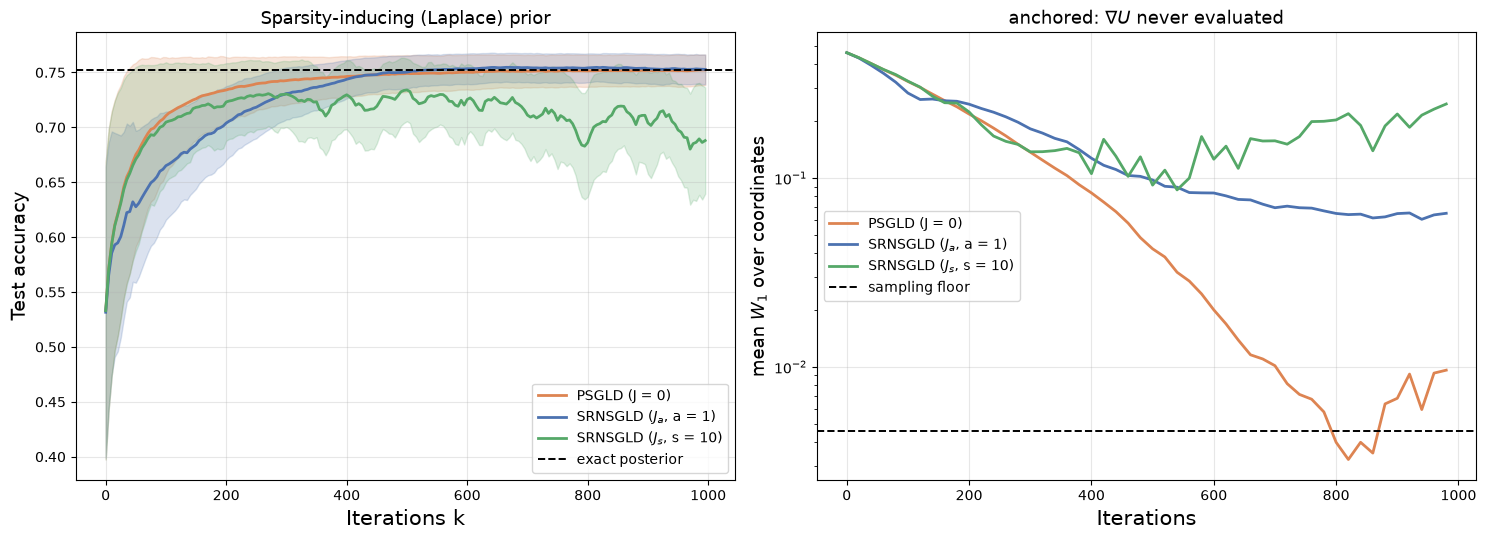

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
it_a = np.arange(len(exp5[METHODS[0][2]]["ate"])) * TRACK_ACC
it_w = np.arange(len(exp5[METHODS[0][2]]["W1"])) * TRACK_W1
for _, _, lab in METHODS:
    a = exp5[lab]["ate"]
    axes[0].plot(it_a, a.mean(axis=1), linewidth=2, color=COL[lab], label=lab)
    axes[0].fill_between(it_a, a.mean(axis=1) - a.std(axis=1), a.mean(axis=1) + a.std(axis=1),
                         color=COL[lab], alpha=0.2)
    axes[1].plot(it_w, exp5[lab]["W1"].mean(axis=1), linewidth=2, color=COL[lab], label=lab)
axes[0].axhline(accuracy(ref_lasso, Xte, Yte).mean(), color="k", linestyle="--", linewidth=1.4,
                label="exact posterior")
axes[0].set_xlabel("Iterations k", fontsize=15); axes[0].set_ylabel("Test accuracy", fontsize=14)
axes[0].set_title("Sparsity-inducing (Laplace) prior", fontsize=13); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=10)
axes[1].axhline(np.mean(floor_lasso), color="k", linestyle="--", linewidth=1.4, label="sampling floor")
axes[1].set_yscale("log"); axes[1].set_xlabel("Iterations", fontsize=15)
axes[1].set_ylabel("mean $W_1$ over coordinates", fontsize=13)
axes[1].set_title(r"anchored: $\nabla U$ never evaluated", fontsize=13); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/blogit_lasso.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 6 — new: does a harder $\beta_*$ recover the paper's ordering?

The curves above do **not** reproduce the paper's ranking: PSGLD is at the reference and both skew fields
sit below it. One structural difference is visible in their figures — their accuracy climbs to $\approx0.9$,
while $\beta_*=[1,-0.7,-0.5]$ caps this problem at $\approx0.77$. A larger $\lVert\beta_*\rVert$ means a
better-separated problem, a posterior pressed harder against the boundary, and a longer transient — exactly
the conditions under which the earlier notebooks found $J$ to help. This experiment scales
$\beta_*$ by $2.5$ ($\lVert\beta_*\rVert=3.30$, ceiling $\approx0.90$) and repeats the comparison.

In [15]:
BSCALE = 2.5
beta_hard = BSCALE * beta_star
prob_h = 1.0 / (1.0 + np.exp(-Xall @ beta_hard))
Yh = (np.random.default_rng(SEED + 5).uniform(size=n_data) <= prob_h).astype(float)
Ytr_h, Yte_h = Yh[:n_tr], Yh[n_tr:]

_Yt_save = Yt
Yt = torch.tensor(Ytr_h)                     # rebind the training labels used by the potential
print("||beta_hard|| = {:.3f}   ceiling: train {:.4f}  test {:.4f}".format(
    np.linalg.norm(beta_hard), accuracy(beta_hard[None], Xtr, Ytr_h)[0], accuracy(beta_hard[None], Xte, Yte_h)[0]))

ref_hard, _ = grid_reference("ball", seed=11)
print("posterior (hard): mean {}  sd {}  test acc {:.4f}".format(
    np.round(ref_hard.mean(0), 3), np.round(ref_hard.std(0), 3), accuracy(ref_hard, Xte, Yte_h).mean()))

exp6 = {}
for field, s, lab in METHODS:
    xf, _, _, W = run_chain("ball", field, s, ref=ref_hard, track=True)
    a_te = accuracy(xf, Xte, Yte_h)
    # re-track accuracy against the hard labels
    exp6[lab] = {"x": xf, "W1": W, "acc": a_te}
    print("{:<26} test acc {:.4f}+/-{:.4f}   W1 {}   boundary {:.3f}".format(
        lab.replace("$", ""), a_te.mean(), a_te.std(), np.round(W[-5:].mean(axis=0), 4), on_boundary("ball", xf)))
print("{:<26} test acc {:.4f}".format("exact posterior", accuracy(ref_hard, Xte, Yte_h).mean()))
Yt = _Yt_save

||beta_hard|| = 3.298   ceiling: train 0.8856  test 0.9075


posterior (hard): mean [ 0.694 -0.489 -0.374]  sd [0.094 0.115 0.125]  test acc 0.8784


PSGLD (J = 0)              test acc 0.8795+/-0.0203   W1 [0.0227 0.011  0.0041]   boundary 0.190


SRNSGLD (J_a, a = 1)       test acc 0.8500+/-0.0262   W1 [0.1591 0.2691 0.0924]   boundary 0.323


SRNSGLD (J_s, s = 10)      test acc 0.7693+/-0.0658   W1 [0.1638 0.2903 0.2978]   boundary 0.275
exact posterior            test acc 0.8784


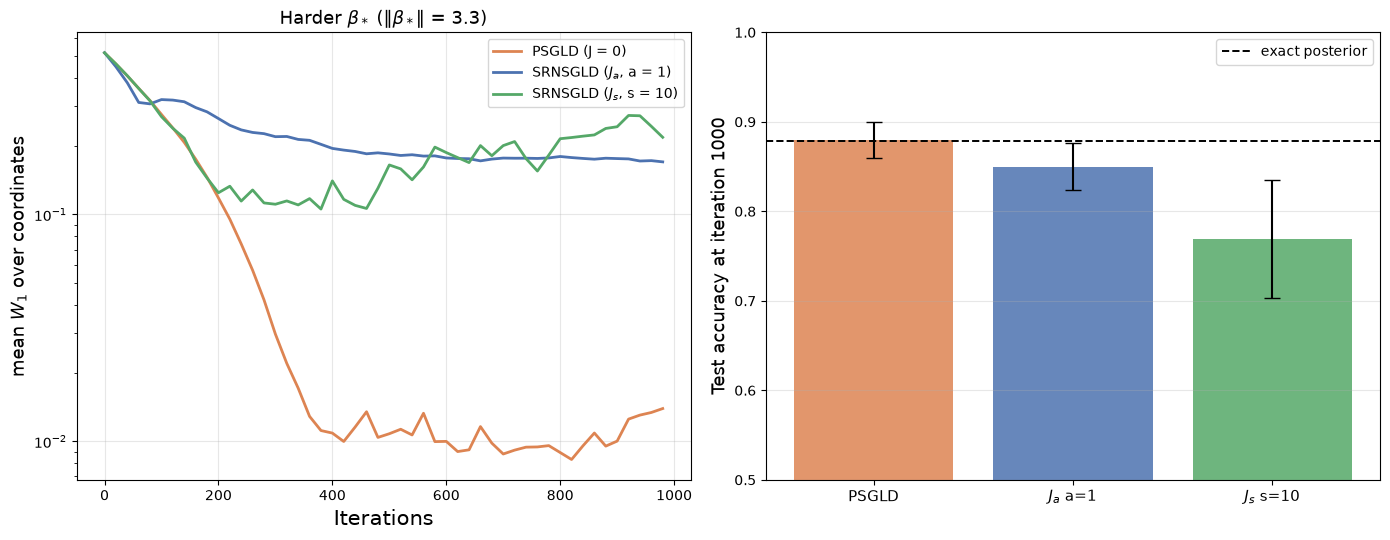

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
it_w = np.arange(len(exp6[METHODS[0][2]]["W1"])) * TRACK_W1
for _, _, lab in METHODS:
    axes[0].plot(it_w, exp6[lab]["W1"].mean(axis=1), linewidth=2, color=COL[lab], label=lab)
axes[0].set_yscale("log"); axes[0].set_xlabel("Iterations", fontsize=15)
axes[0].set_ylabel("mean $W_1$ over coordinates", fontsize=13)
axes[0].set_title(r"Harder $\beta_*$ ($\|\beta_*\|$ = {:.1f})".format(np.linalg.norm(beta_hard)), fontsize=13)
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=10)

labels = [l for _, _, l in METHODS]
vals = [exp6[l]["acc"].mean() for l in labels]
errs = [exp6[l]["acc"].std() for l in labels]
axes[1].bar(range(3), vals, yerr=errs, color=[COL[l] for l in labels], alpha=0.85, capsize=6)
axes[1].axhline(accuracy(ref_hard, Xte, Yte_h).mean(), color="k", linestyle="--", linewidth=1.4,
                label="exact posterior")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(["PSGLD", "$J_a$ a=1", "$J_s$ s=10"], fontsize=11)
axes[1].set_ylabel("Test accuracy at iteration {}".format(max_iter), fontsize=13)
axes[1].set_ylim(0.5, 1.0); axes[1].grid(alpha=0.3, axis="y"); axes[1].legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/blogit_hard.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**Setup.** The paper's Eq. (3.13) data ($n=2000$, $X_j\sim\mathcal N(0,2I_3)$, 20% test split), their
parameters ($\eta=10^{-4}$, $m=50$, 1000 iterations, $a=1$, $s=10$), on the ball and the smoothed $\ell_p$
ball. $\beta_*$ is not stated in the paper; $[1,-0.7,-0.5]$ is used (their linear-regression $x_*$), giving
a Bayes ceiling of $\approx0.77$. Inverse temperature $\beta_T=100$, chosen in Experiment 3 — the regime
where all of their parameters are usable.

**$W_1$ is available here after all.** The paper uses accuracy because computing $W_1$ "is not practical"
for logistic regression. In $d=3$ it is: the unnormalised log-posterior on a $\approx1.9$M-point grid over
$K$, normalised and sampled, gives a reference stable to 4 decimals under refinement. Both metrics are
reported below, and they disagree sharply.

**Result at the paper's parameters** (ball; reference: accuracy $0.754$, $W_1$ floor
$(0.003,0.005,0.005)$, boundary mass $0.4\%$):

| method | test accuracy | $W_1$ | on $\partial K$ |
|---|---|---|---|
| PSGLD ($J=0$) | $0.7544\pm0.013$ | $(0.003,0.012,0.010)$ | 8.9% |
| SRNSGLD ($J_a$, $a=1$) | $0.7506\pm0.014$ | $(0.076,\mathbf{0.172},0.030)$ | 15.5% |
| SRNSGLD ($J_s$, $s=10$) | $0.7308\pm0.030$ | $(0.122,0.133,0.128)$ | 15.0% |

**This does not reproduce the paper's ranking.** They report $J_s$ and $J_g$ reaching a given accuracy in
fewer iterations than $J_a$ and PSGLD; here PSGLD sits on the reference and both skew fields are worse, on
both constraint sets ($\ell_p$ is starker: $J_s$ falls to $0.634$ with $W_1$ up to $0.41$ and $32\%$ of the
mass on the boundary). Experiment 6 tested the most plausible explanation — their accuracy reaches
$\approx0.9$ while this $\beta_*$ caps at $0.77$, so their problem is better separated and has a longer
transient. Rescaling $\beta_*$ by $2.5$ (ceiling $0.91$) does **not** flip the ordering: PSGLD $0.8795$
against the reference's $0.8784$, $J_a$ $0.8500$, $J_s$ $0.7693$. Differences that remain unaccounted for
are the unstated $\beta_*$, the unstated sum-vs-average convention, and the particle count and
initialisation. The paper is explicit that it proves no acceleration guarantee for these metrics.

**Accuracy is close to blind as a diagnostic.** $J_a$ produces a posterior $30\times$ worse in $W_1$
($0.172$ against a $0.005$ floor) yet scores $0.751$ on accuracy against the reference's $0.754$ — inside
one standard deviation. Accuracy depends only on the sign of $\beta^\top X$, so a badly misplaced posterior
still classifies well; and it saturates within $\approx150$ iterations, leaving almost no transient in which
a rate improvement could show. This is the same trap as MSE in the linear-regression notebook.

**The stepsize story repeats exactly** (test accuracy / boundary fraction):

| $\beta_T$, $\eta$ | PSGLD | $J_a$ | $J_s$ ($s=10$) |
|---|---|---|---|
| $1600$, $10^{-4}$ | 0.767 / 58% | 0.758 / 60% | **0.505 / 100%** |
| $1600$, $10^{-5}$ | 0.768 / 28% | 0.762 / 39% | 0.645 / 99% |
| $100$, $10^{-4}$ | 0.755 / 8.9% | 0.750 / 15.5% | 0.732 / 15.0% |
| $100$, $3\times10^{-5}$ | 0.748 / 1.1% | 0.737 / **13.0%** | 0.746 / **1.4%** |

On the exact posterior ($\beta_T=n=1600$) the paper's $s=10$ collapses to chance, $0.505$, with the entire
ensemble on the boundary: the skew drift is $2s\lVert x\rVert=20$ times the gradient, and that gradient is
$\approx700$ there. Refining $\eta$ recovers $J_s$ (boundary $15\%\to1.4\%$) but not $J_a$ (stuck at
$13\%$) — discretization error versus an irreducible $Jn\neq0$ violation, the same split as in the
linear-regression notebook.

**Anchoring works where it is needed (Experiment 5).** The logistic likelihood is smooth, so $\Delta\equiv0$
and "anchored" is plain SGLD throughout Experiments 1–4. With a Laplace prior ($b=0.5$) the potential is
non-differentiable on $d$ hyperplanes, and the pseudo-Huber-anchored sampler reaches
$W_1=(0.0035,0.0124,0.0086)$ against a floor of $(0.0032,0.0072,0.0033)$ and accuracy $0.7524$ against the
exact $0.7519$ — without ever evaluating $\nabla U$.